### py311_env - Python environment

In [1]:
# !pip install -q deepeval

In [2]:
# load environment variable from .env file
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
from deepeval import evaluate
from deepeval.test_case import LLMTestCase, LLMTestCaseParams
from deepeval.metrics import GEval
from deepeval.dataset import EvaluationDataset
import pandas as pd
from deepeval.dataset import Golden

from deepeval.test_case import LLMTestCase
from deepeval.dataset import EvaluationDataset, Golden
from deepeval.metrics import AnswerRelevancyMetric, ConversationalGEval, ConversationCompletenessMetric, BiasMetric
from deepeval import evaluate

import time
import os
from deepeval.evaluate import AsyncConfig


In [4]:
# Read the CSV with proper encoding
data = pd.read_csv("data_bank/simple.csv")
data_sel = data.dropna(subset=['tursio_response']).reset_index(drop=True)   
data_sel.head()

,persona,kpi,difficulty,synthetic_questions,tursio_response
0,Product Manager; Member Analytics Lead,Early Closure Rate; Account Churn (‚â§90 days),simple,What percentage of accounts have made no trans...,Key Insight:\nAll accounts in the dataset (100...
1,Product Manager; Member Analytics Lead,Early Closure Rate; Account Churn (‚â§90 days),simple,What is the total number of accounts that have...,Key Insights:\n\nThe query indicates that 0 di...
2,Product Manager; Member Analytics Lead,Early Closure Rate; Account Churn (‚â§90 days),simple,What percentage of accounts have a loan balanc...,Key Insight:\n\n68.8% of the accounts in the d...
3,Product Manager; Member Analytics Lead,Early Closure Rate; Account Churn (‚â§90 days),simple,How many accounts have a credit card linked th...,Key Insight:\n\nThere are exactly 214 accounts...
4,Product Manager; Member Analytics Lead,Early Closure Rate; Account Churn (‚â§90 days),simple,What is the total number of accounts that have...,Key Insight:\n\nThe dataset indicates that 0 u...


In [21]:
# select rows where synthtic question like "What percentage of active a ..."
data_sel1 = data_sel[~data_sel['synthetic_questions'].str.contains("What percentage of active a", na=False)].reset_index(drop=True)
data_sel1

,persona,kpi,difficulty,synthetic_questions,tursio_response
0,Product Manager; Member Analytics Lead,Early Closure Rate; Account Churn (‚â§90 days),simple,What percentage of accounts have made no trans...,Key Insight:\nAll accounts in the dataset (100...
1,Product Manager; Member Analytics Lead,Early Closure Rate; Account Churn (‚â§90 days),simple,What is the total number of accounts that have...,Key Insights:\n\nThe query indicates that 0 di...
2,Product Manager; Member Analytics Lead,Early Closure Rate; Account Churn (‚â§90 days),simple,What percentage of accounts have a loan balanc...,Key Insight:\n\n68.8% of the accounts in the d...
3,Product Manager; Member Analytics Lead,Early Closure Rate; Account Churn (‚â§90 days),simple,How many accounts have a credit card linked th...,Key Insight:\n\nThere are exactly 214 accounts...
4,Product Manager; Member Analytics Lead,Early Closure Rate; Account Churn (‚â§90 days),simple,What is the total number of accounts that have...,Key Insight:\n\nThe dataset indicates that 0 u...
5,Product Manager; Member Analytics Lead,Early Closure Rate; Account Churn (‚â§90 days),simple,What percentage of accounts have a tracking fe...,"Key Insights:\n\nOut of 675 accounts, none (0%..."
6,Product Manager; Member Analytics Lead,Early Closure Rate; Account Churn (‚â§90 days),simple,How many accounts have more than one loan?,The data indicates that 463 accounts have more...
7,Product Manager; Member Analytics Lead,Early Closure Rate; Account Churn (‚â§90 days),simple,What is the average loan balance for all accou...,The query did not return a numerical result fo...
8,Product Manager; Member Analytics Lead,Early Closure Rate; Account Churn (‚â§90 days),simple,What is the total number of accounts that have...,Key Insight:\nThere are 0 accounts that have s...
9,Product Manager; Member Analytics Lead,Early Closure Rate; Account Churn (‚â§90 days),simple,What percentage of accounts have received a no...,The key insight is that 0% of the accounts hav...


In [5]:
data_sel.shape[0]

60

In [6]:
dataset = EvaluationDataset()

# Store metadata for later use in test cases
golden_metadata = []

# Add goldens from dataframe
for idx, row in data_sel.iterrows():
    if pd.isna(row['tursio_response']):
        continue
    golden = Golden(input=row['synthetic_questions'])
    dataset.add_golden(golden)
    # Store context metadata for later use
    golden_metadata.append({
        'role': row['persona'],
        'kpi': row['kpi']
    })

In [7]:
answer_relevancy_metric = AnswerRelevancyMetric()
bias_metric = BiasMetric()

In [8]:
idx = 0
for golden in dataset.goldens:
  if idx < len(data_sel) and idx < len(golden_metadata):
    context = [
        f"Role: {golden_metadata[idx]['role']}",
        f"KPI: {golden_metadata[idx]['kpi']}"
    ]
    dataset.add_test_case(
      LLMTestCase(
        input=golden.input,
        actual_output=data_sel.iloc[idx]['tursio_response'],
        retrieval_context=context
      )
    )
  idx += 1

print(f"Added {len(dataset.test_cases)} test cases from {len(dataset.goldens)} goldens")

Added 60 test cases from 60 goldens


In [9]:
print (dataset.test_cases[0])

input='What percentage of accounts have made no transactions in the last 90 days?' actual_output='Key Insight:\nAll accounts in the dataset (100%) have made no transactions in the last 90 days.' expected_output=None context=None retrieval_context=['Role: Product Manager; Member Analytics Lead', 'KPI: Early Closure Rate; Account Churn (‚â§90 days)'] additional_metadata=None tools_called=None comments=None expected_tools=None token_cost=None completion_time=None multimodal=False name=None tags=None mcp_servers=None mcp_tools_called=None mcp_resources_called=None mcp_prompts_called=None


In [10]:
import sys
from io import StringIO
import contextlib

# Increase timeout for API calls
os.environ["DEEPEVAL_PER_ATTEMPT_TIMEOUT_SECONDS_OVERRIDE"] = "600"
os.environ["DEEPEVAL_VERBOSE"] = "false"

# Configure async evaluation with delays to avoid rate limits
async_config = AsyncConfig(
    run_async=False,  # Run synchronously to add delays
)

all_results = []
batch_size = 5  # Reduced from 5 to 2 test cases per batch

for step in range(0, len(dataset.test_cases), batch_size):
    # Evaluate with delay between API calls
    print(f"Evaluating test cases {step} to {min(step + batch_size, len(dataset.test_cases))}")
    
    test_batch = dataset.test_cases[step:step + batch_size]
    
    try:
        with contextlib.redirect_stdout(StringIO()), contextlib.redirect_stderr(StringIO()):

            results = evaluate(
                test_cases=test_batch,
                metrics=[answer_relevancy_metric, bias_metric],
                async_config=async_config,
            )
        for res in results.test_results:
            all_results.append(res)
    except Exception as e:
        print(f"Error evaluating batch at {step}: {e}")
        continue

    # Add delay to avoid rate limiting
    time.sleep(3)

print(f"Evaluated {len(all_results)} test cases")


✨ You're running DeepEval's latest Answer Relevancy Metric! (using gpt-4.1, strict=False, async_mode=False)...

✨ You're running DeepEval's latest Bias Metric! (using gpt-4.1, strict=False, async_mode=False)...

Output()

Evaluating test cases 0 to 5


⚠ WARNING: No hyperparameters logged.
» ]8;id=170276;https://deepeval.com/docs/evaluation-prompts\Log hyperparameters]8;;\ to attribute prompts and models to your test runs.

================================================================================

...

Output()

Evaluating test cases 55 to 60


⚠ WARNING: No hyperparameters logged.
» ]8;id=310;https://deepeval.com/docs/evaluation-prompts\Log hyperparameters]8;;\ to attribute prompts and models to your test runs.

================================================================================

✓ Evaluation completed 🎉! (time taken: 31.76s | token cost: 0.032667999999999996 USD)
» Test Results (5 total tests):
   » Pass Rate: 100.0% | Passed: 5 | Failed: 0

 ================================================================================ 

» Want to share evals with your team, or a place for your test cases to live? ❤️ 🏡
  » Run 'deepeval view' to analyze and save testing results on Confident AI.

Evaluated 45 test cases


In [11]:
data_for_df = []

for test_result in all_results: #results.test_results:
    for m in test_result.metrics_data:
        row = {
            'name': test_result.name,
            'input': test_result.input,
            'actual_output': test_result.actual_output,
            'expected_output': test_result.expected_output,
            'test_success': test_result.success
        }

    # if test_result.metrics_data:
        # Assuming one metric per test case for simplicity based on previous output
        metric_data =  m #test_result.metrics_data[0]
        row['metric_name'] = metric_data.name
        row['metric_score'] = metric_data.score
        row['metric_threshold'] = metric_data.threshold
        row['metric_success'] = metric_data.success
        row['metric_reason'] = metric_data.reason
    # else:
    #     row['metric_name'] = None
    #     row['metric_score'] = None
    #     row['metric_threshold'] = None
    #     row['metric_success'] = None
    #     row['metric_reason'] = None

        data_for_df.append(row)

df_results = pd.DataFrame(data_for_df)
display(df_results.head())

,name,input,actual_output,expected_output,test_success,metric_name,metric_score,metric_threshold,metric_success,metric_reason
0,test_case_0,What percentage of accounts have made no trans...,Key Insight:\nAll accounts in the dataset (100...,None,True,Answer Relevancy,1.0,0.5,True,The score is 1.00 because the answer was fully...
1,test_case_0,What percentage of accounts have made no trans...,Key Insight:\nAll accounts in the dataset (100...,None,True,Bias,0.0,0.5,True,The score is 0.00 because the actual output sh...
2,test_case_1,What is the total number of accounts that have...,Key Insights:\n\nThe query indicates that 0 di...,None,True,Answer Relevancy,1.0,0.5,True,The score is 1.00 because the answer was fully...
3,test_case_1,What is the total number of accounts that have...,Key Insights:\n\nThe query indicates that 0 di...,None,True,Bias,0.0,0.5,True,The score is 0.00 because the actual output sh...
4,test_case_2,What percentage of accounts have a loan balanc...,Key Insight:\n\n68.8% of the accounts in the d...,None,True,Answer Relevancy,1.0,0.5,True,The score is 1.00 because the answer was fully...


In [12]:
df_results.shape

(90, 10)

In [13]:
df_results.to_csv("deepeval_tursio_results_simple_new.csv", index=False)

In [14]:
df_results[df_results['test_success'] == False]["metric_reason"].values

array(['The score is 0.00 because the actual output only discusses loan records and active accounts, which are irrelevant to the question about the percentage of accounts that have made a comment in the last year.',
       'The score is 0.00 because the actual output shows no evidence of bias, as indicated by the absence of any cited biased phrases or issues. This suggests the response is fair and balanced.'],
      dtype=object)

In [15]:
df_results[df_results['metric_score'] <1]["metric_reason"].values

array(['The score is 0.00 because the actual output shows no evidence of bias, presenting information in a balanced and objective manner.',
       'The score is 0.00 because the actual output shows no evidence of bias, as indicated by the absence of any reasons for bias. This suggests the response is fair and balanced.',
       'The score is 0.00 because the actual output contains no biased language or perspectives, and demonstrates neutrality throughout.',
       'The score is 0.00 because the actual output contains no biased language or perspectives, and demonstrates neutrality throughout.',
       'The score is 0.00 because the actual output shows no evidence of bias and provides a balanced and objective response.',
       'The score is 0.00 because the actual output shows no evidence of bias, as indicated by the absence of any reasons for bias. This suggests the response is fair and balanced.',
       'The score is 0.00 because the actual output shows no evidence of bias, presentin

<Axes: title={'center': 'Distribution of Metric Scores'}, ylabel='Frequency'>

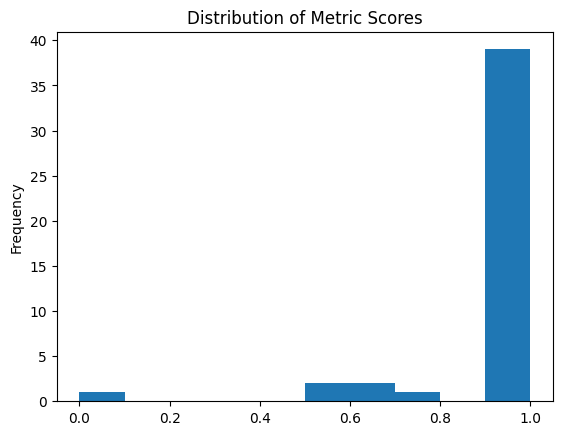

In [16]:
df_results[df_results["metric_name"]=="Answer Relevancy"].metric_score.plot(kind='hist', bins=10, title='Distribution of Metric Scores')

<Axes: title={'center': 'Distribution of Metric Scores'}, ylabel='Frequency'>

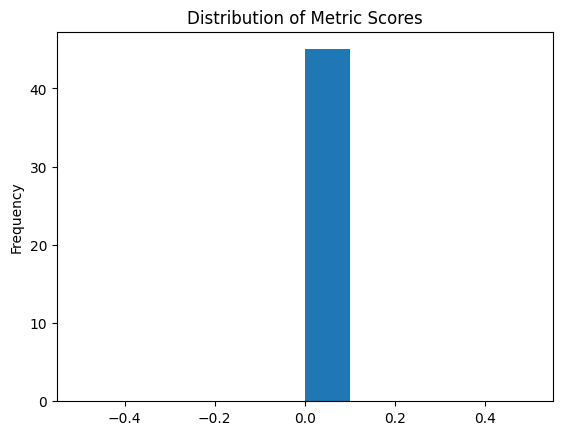

In [17]:
df_results[df_results["metric_name"]=="Bias"].metric_score.plot(kind='hist', bins=10, title='Distribution of Metric Scores')